In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
import yfinance as yf

data = yf.download("AAPL",
                   start="2020-01-01",
                   end="2025-01-01")

data.reset_index(inplace=True)

data.to_csv("apple_stock.csv")

[*********************100%***********************]  1 of 1 completed


In [3]:
df = pd.read_csv("apple_stock.csv")

In [4]:
print(df.columns)

Index(['Price', 'Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [5]:
df.head(10)

,Price,Date,Close,High,Low,Open,Volume
0,Ticker,NaN,AAPL,AAPL,AAPL,AAPL,AAPL
1,0,2020-01-02,72.33385467529297,72.39406264366768,71.09116132608638,71.34403185341793,135480400
2,1,2020-01-03,71.63065338134766,72.38927264137095,71.40668140593664,71.56322072155912,146322800
3,2,2020-01-06,72.201416015625,72.23995000976231,70.50355369984423,70.75402098693286,118387200
4,3,2020-01-07,71.86185455322266,72.46633779595872,71.6426965801033,72.21105649751387,108872000
5,4,2020-01-08,73.0178451538086,73.31888511458335,71.56562867701548,71.56562867701548,132079200
6,5,2020-01-09,74.56880950927734,74.76147215954668,73.74275755557424,73.9932175310026,170108400
7,6,2020-01-10,74.73736572265625,75.30091887725054,74.23643856809193,74.80239504412852,140644800
8,7,2020-01-13,76.33409881591797,76.36059415429726,74.93486566437117,75.05287832688332,121532000
9,8,2020-01-14,75.30333709716797,76.48100893453174,75.18051779267843,76.27148630079421,161954400


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   1259 non-null   object
 1   Date    1258 non-null   object
 2   Close   1259 non-null   object
 3   High    1259 non-null   object
 4   Low     1259 non-null   object
 5   Open    1259 non-null   object
 6   Volume  1259 non-null   object
dtypes: object(7)
memory usage: 69.0+ KB


In [7]:
df.describe()

,Price,Date,Close,High,Low,Open,Volume
count,1259,1258,1259,1259,1259,1259,1259
unique,1259,1258,1244,1259,1259,1259,1257
top,1257,2024-12-31,88.13536071777344,251.6720440162376,247.84647977817443,250.83738041728796,97918500
freq,1,1,2,1,1,1,2


In [8]:
df.isnull().sum()

Price     0
Date      1
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.fillna(method='ffill', inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_8976\3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [12]:
df["Date"] = pd.to_datetime(df["Date"])

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Price   1259 non-null   object        
 1   Date    1258 non-null   datetime64[ns]
 2   Close   1259 non-null   object        
 3   High    1259 non-null   object        
 4   Low     1259 non-null   object        
 5   Open    1259 non-null   object        
 6   Volume  1259 non-null   object        
dtypes: datetime64[ns](1), object(6)
memory usage: 69.0+ KB


In [14]:
df.sort_values("Date", inplace=True)

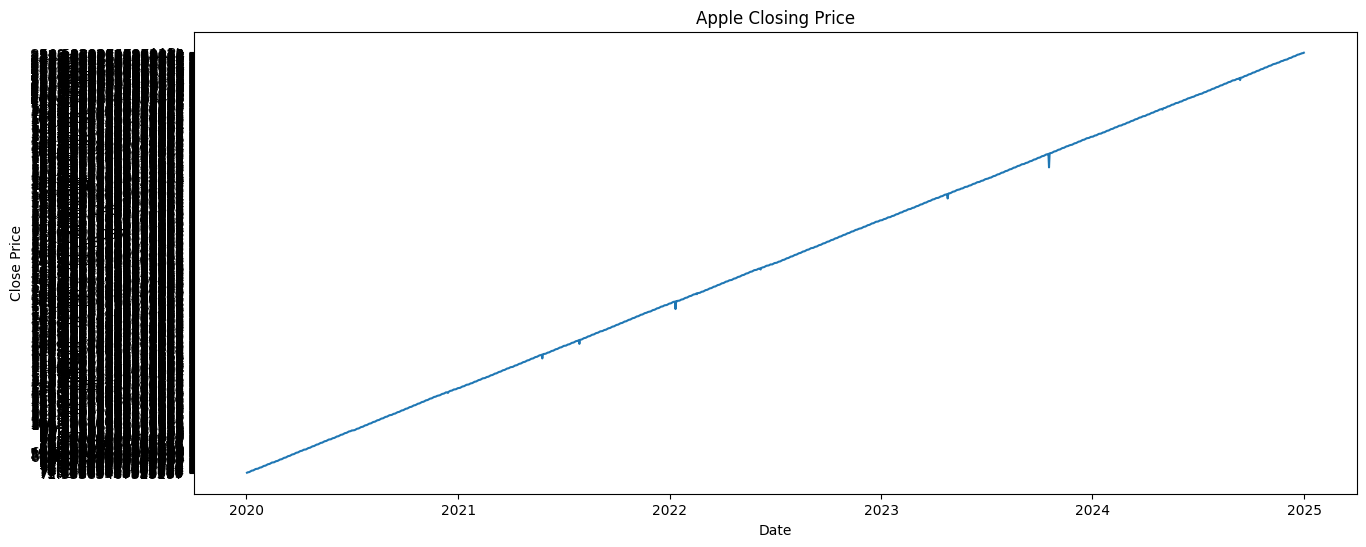

In [15]:
plt.figure(figsize=(15,6))
plt.plot(df["Date"], df["Close"])
plt.title("Apple Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

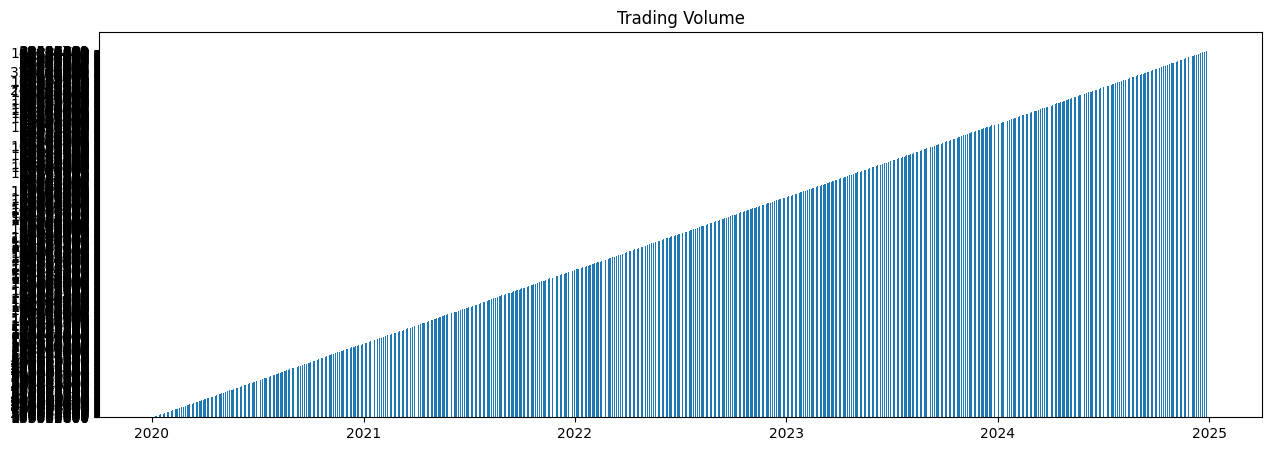

In [16]:
plt.figure(figsize=(15,5))
plt.bar(df["Date"], df["Volume"])
plt.title("Trading Volume")
plt.show()

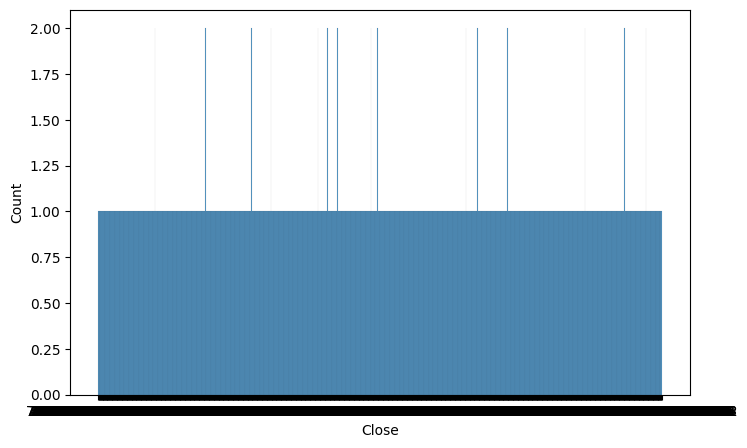

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df["Close"], bins=30)
plt.show()

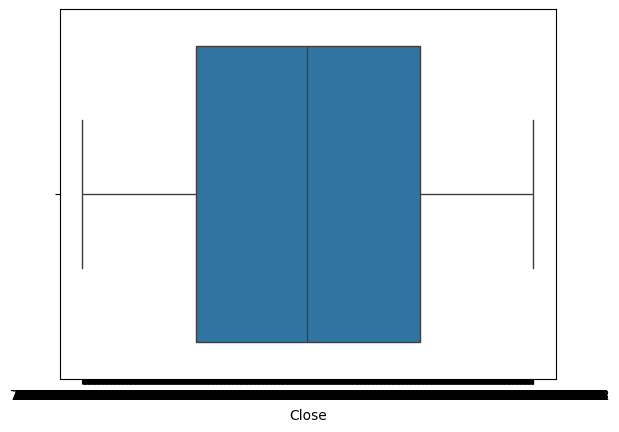

In [21]:
sns.boxplot(x=df["Close"])
plt.show()

In [25]:
df["Date"] = pd.to_datetime(df["Date"])

cols = ["Close", "High", "Low", "Open", "Volume"]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1259 entries, 1 to 0
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Price   1259 non-null   object        
 1   Date    1258 non-null   datetime64[ns]
 2   Close   1258 non-null   float64       
 3   High    1258 non-null   float64       
 4   Low     1258 non-null   float64       
 5   Open    1258 non-null   float64       
 6   Volume  1258 non-null   float64       
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 78.7+ KB


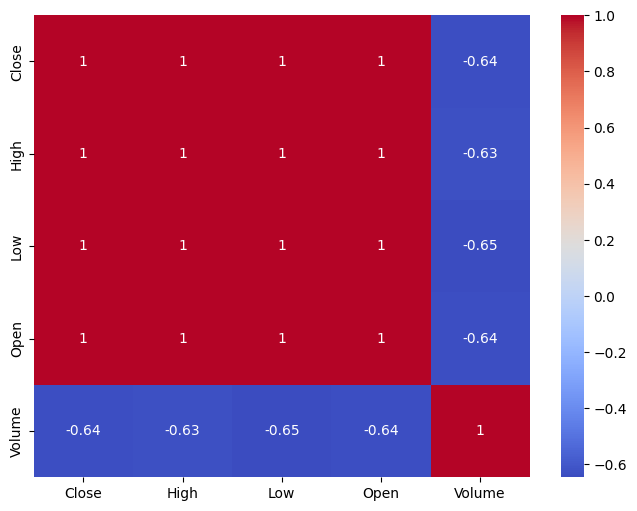

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [34]:
df["Day"] = np.arange(len(df))
df = df.dropna(subset=["Close", "Open", "High", "Low", "Volume"])

In [35]:
X = df[["Day"]]
y = df["Close"]

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [38]:
y_pred = model.predict(X_test)

In [39]:
print("MAE:", mean_absolute_error(y_test,y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2:", r2_score(y_test,y_pred))

MAE: 14.442046271847843
RMSE: 17.192529949324342
R2: 0.8292099422364909


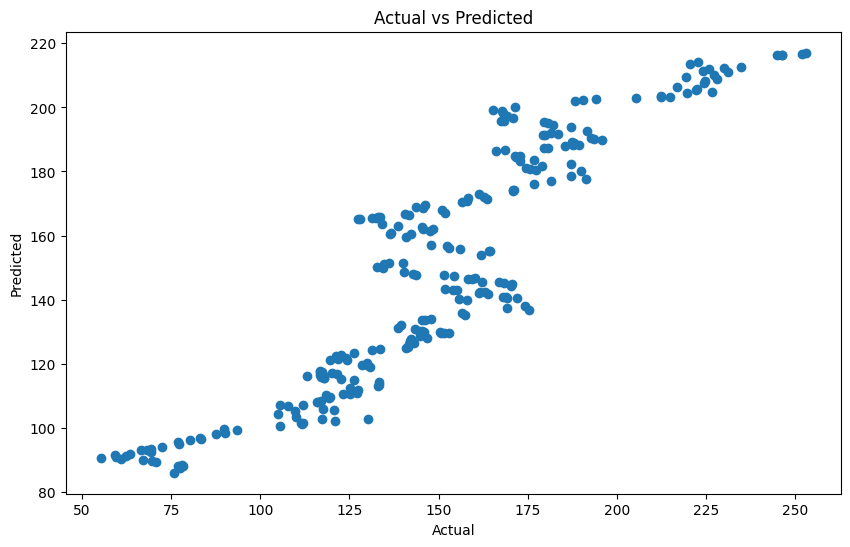

In [40]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [41]:
future_day = [[len(df)+30]]

future_price = model.predict(future_day)

print(future_price)

[220.96524486]


c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
